<a href="https://colab.research.google.com/github/ricardoOliveiraN/rna-brasileirao/blob/main/rna_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pickle as pck
import pandas as pd
from google.colab import drive
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configurações

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

#DATASET

### BIBLIOTECA DE ATRIBUTOS:



* gols_mandante: conversão numérica do placar do mandante para cálculos.
* gols_visitante: conversão numérica do placar do visitante para cálculos.
* pontos_mandante: pontuação ganha pelo mandante no jogo (3 para vitória, 1 para empate, 0 para derrota).
* pontos_visitante: pontuação ganha pelo visitante no jogo (3 para vitória, 1 para empate, 0 para derrota).
* mgm_casa: média de gols marcados pelo mandante quando joga dentro de casa.
* mgs_casa: média de gols sofridos (tomados) pelo mandante quando joga dentro de casa
* apr_casa: percentual de aproveitamento de pontos do mandante nos jogos em casa (pontos ganhos / 30 possíveis).
* mgm_fora: média de gols marcados pelo visitante quando joga fora de casa.
* mgs_fora: média de gols sofridos (tomados) pelo visitante quando joga fora de casa.
* apr_fora: percentual de aproveitamento de pontos do visitante nos jogos fora de casa.
* dif_aproveitamento: confronto de regularidade (Aproveitamento do Mandante em Casa menos o Aproveitamento do Visitante Fora).
* dif_ataque: confronto de força ofensiva (Média de gols que o mandante faz em casa menos a média de gols que o visitante sofre fora).
* dif_defesa: confronto de força defensiva (Média de gols que o mandante sofre em casa menos a média de gols que o visitante faz fora).
* resultado: o gabarito que a IA tentará adivinhar (2 para vitória do mandante, 1 para empate, 0 para vitória do visitante).


### Inicia data frame

In [5]:
# conectar com google drive
drive.mount('/content/drive')

# caminho do arquivo
caminho_arquivo = "/content/drive/MyDrive/campeonato-brasileiro-full.csv"

# extrair arquivos do google drive
df = pd.read_csv(caminho_arquivo)

#print(df.head())

Mounted at /content/drive


In [6]:
print(display(df))

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8780,8783,38,08/12/2024,16:04,Cuiaba,Vasco,4-3-3,4-3-2-1,B. Franco,F. Loureiro,Vasco,Arena Pantanal,1,2,MT,RJ
8781,8784,38,08/12/2024,16:04,Palmeiras,Fluminense,4-2-3-1,4-2-3-1,A. Moreira Ferreira,L. Venker de Menezes,Fluminense,Allianz Parque,0,1,SP,RJ
8782,8776,38,08/12/2024,16:05,Fortaleza,Internacional,4-2-3-1,4-1-2-1-2,J. Vojvoda,R. Machado Marques,Fortaleza,Arena Castelão,3,0,CE,RS
8783,8780,38,08/12/2024,16:05,Bragantino,Criciuma,4-2-3-1,4-1-2-1-2,F. Seabra,C. Tencati,Bragantino,Nabizão,5,1,SP,SC


None


### Ajustar tipos e cronologia

In [7]:
df["data"] = pd.to_datetime(
    df["data"],
    format="%d/%m/%Y"
)

df["gols_mandante"] = pd.to_numeric(df["mandante_Placar"])
df["gols_visitante"] = pd.to_numeric(df["visitante_Placar"])

df = (
    df
    .sort_values("data")
    .reset_index(drop=True)
)


### Criar pontos

In [8]:
df["pontos_mandante"] = np.where(
    df["gols_mandante"] > df["gols_visitante"],
    3,
    np.where(
        df["gols_mandante"] == df["gols_visitante"],
        1,
        0
    )
)

df["pontos_visitante"] = np.where(
    df["gols_visitante"] > df["gols_mandante"],
    3,
    np.where(
        df["gols_visitante"] == df["gols_mandante"],
        1,
        0
    )
)


### Histórico mandante

In [9]:
df["mgm_casa"] = (
    df.groupby("mandante")["gols_mandante"]
      .transform(
          lambda x:
          x.shift(1).rolling(10).mean()
      )
)

df["mgs_casa"] = (
    df.groupby("mandante")["gols_visitante"]
      .transform(
          lambda x:
          x.shift(1).rolling(10).mean()
      )
)

df["apr_casa"] = (
    df.groupby("mandante")["pontos_mandante"]
      .transform(
          lambda x:
          x.shift(1).rolling(10).sum() / 30
      )
)

### Histórico visitante

In [10]:
df["mgm_fora"] = (
    df.groupby("visitante")["gols_visitante"]
      .transform(
          lambda x:
          x.shift(1).rolling(10).mean()
      )
)

df["mgs_fora"] = (
    df.groupby("visitante")["gols_mandante"]
      .transform(
          lambda x:
          x.shift(1).rolling(10).mean()
      )
)

df["apr_fora"] = (
    df.groupby("visitante")["pontos_visitante"]
      .transform(
          lambda x:
          x.shift(1).rolling(10).sum() / 30
      )
)

### Features finais

In [11]:
df["dif_aproveitamento"] = (
    df["apr_casa"] -
    df["apr_fora"]
)

df["dif_ataque"] = (
    df["mgm_casa"] -
    df["mgs_fora"]
)

df["dif_defesa"] = (
    df["mgs_casa"] -
    df["mgm_fora"]
)


### Resultado (y)

In [12]:
df["resultado"] = np.where(
    df["gols_mandante"] > df["gols_visitante"],
    2,
    np.where(
        df["gols_mandante"] == df["gols_visitante"],
        1,
        0
    )
)


### Limpando os dados a serem utilizados

In [13]:
colunas_importantes = [
    "data",
    "resultado",
    "mgm_casa", "mgs_casa", "apr_casa",
    "mgm_fora", "mgs_fora", "apr_fora",
    "dif_aproveitamento", "dif_ataque", "dif_defesa"
]

# cria um data frame com apenas as colunas importantes.
df_modelo = df[colunas_importantes].dropna().copy()

# definindo os campos de input do df a ser usado pela IA
x = df_modelo[
    [
        "mgm_casa", "mgs_casa", "apr_casa",
        "mgm_fora", "mgs_fora", "apr_fora",
        "dif_aproveitamento", "dif_ataque", "dif_defesa"
    ]
]

# definindo o output do df a ser usado pela IA
y = df_modelo["resultado"]

# criando as máscaras booleanas baseadas no ano (para filtrar)
filtro_treino = df_modelo["data"].dt.year < 2024
filtro_teste = df_modelo["data"].dt.year == 2024

# separando os dados de Treino (2003-2023)
x_train = x[filtro_treino]
y_train = y[filtro_treino]

# separando os dados de Teste (2024)
x_test = x[filtro_teste]
y_test = y[filtro_teste]

print(f"Valores do x_train: {x_train.head()}")
print(f"Valores do x_test: {x_test.head()}")

print(f"Valores do y_train: {y_train.head()}")
print(f"Valores do y_test: {y_test.head()}")

print(f"Formato do X_train: {x_train.shape}")
print(f"Formato do X_test:  {x_test.shape}")

Valores do x_train:      mgm_casa  mgs_casa  apr_casa  mgm_fora  mgs_fora  apr_fora  dif_aproveitamento  dif_ataque  dif_defesa
225       1.1       0.8  0.466667       1.6       1.4  0.433333            0.033333        -0.3        -0.8
227       2.0       0.9  0.566667       1.3       1.9  0.266667            0.300000         0.1        -0.4
234       1.4       0.5  0.766667       1.2       2.0  0.333333            0.433333        -0.6        -0.7
242       2.2       1.0  0.733333       1.3       2.4  0.133333            0.600000        -0.2        -0.3
247       1.7       1.1  0.633333       1.1       1.8  0.233333            0.400000        -0.1         0.0
Valores do x_test:       mgm_casa  mgs_casa  apr_casa  mgm_fora  mgs_fora  apr_fora  dif_aproveitamento  dif_ataque  dif_defesa
8405       2.0       1.3  0.566667       1.7       2.0  0.300000            0.266667         0.0        -0.4
8406       1.1       1.1  0.400000       0.3       2.4  0.000000            0.400000        -1.

### Transforma o y (output) em 3 saídas possíveis.

In [14]:
# get_dummies: ele lê os dados e vê quais valores são diferentes (nesse caso temos 0, 1 e 2), depois cria a quantidade de colunas referentes
# de modo que vire uma matriz com mais de uma coluna
# O valor 0 vira [1, 0, 0] (ativando a primeira coluna) -> vitoria visitante.
# O valor 1 vira [0, 1, 0] (ativando a segunda coluna) -> empate.
# O valor 2 vira [0, 0, 1] (ativando a terceira coluna) -> vitoria mandante.
y_train_encoded = pd.get_dummies(y_train)
y_test_encoded = pd.get_dummies(y_test)

print(y_train_encoded.head())

         0      1      2
225  False  False   True
227  False  False   True
234  False  False   True
242  False   True  False
247  False   True  False


### Plotar o gráfico

Variância explicada: [0.32724101 0.31827348]
Total: 64.6%


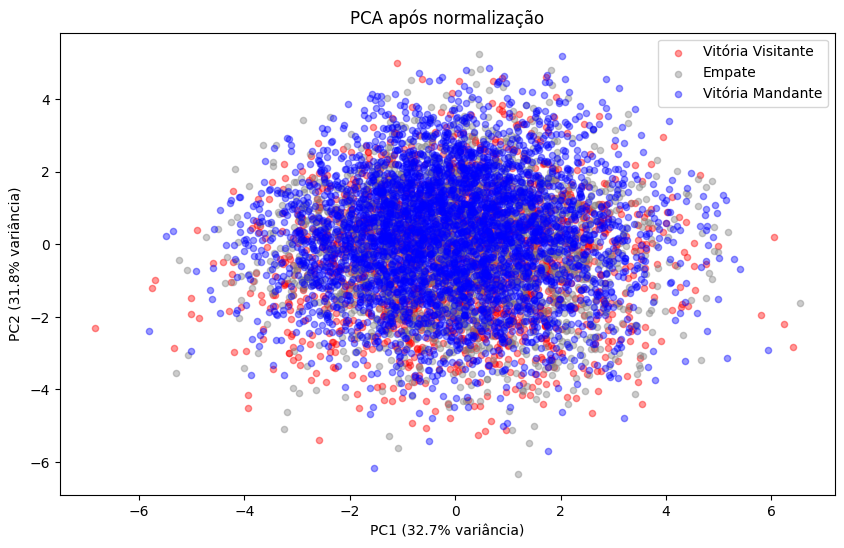

In [15]:
# sempre normalizar antes do PCA -> eu apenas normalizo os dados que serão usados para treinar a IA
scaler = StandardScaler()
x_scaled_train = scaler.fit_transform(x_train)

# depois o PCA
pca = PCA(n_components=2)
x_reduzido = pca.fit_transform(x_scaled_train)

print(f"Variância explicada: {pca.explained_variance_ratio_}")
print(f"Total: {sum(pca.explained_variance_ratio_):.1%}")

# plot com cores discretas (fica mais legível)

y_para_grafico = np.argmax(y_train_encoded.values, axis=1)
cores = {0: 'red', 1: 'gray', 2: 'blue'}
nomes = {0: 'Vitória Visitante', 1: 'Empate', 2: 'Vitória Mandante'}

plt.figure(figsize=(10, 6))
for classe in [0, 1, 2]:
    mask = y_para_grafico == classe
    plt.scatter(x_reduzido[mask, 0], x_reduzido[mask, 1],
                c=cores[classe], label=nomes[classe], alpha=0.4, s=20)

plt.legend()
plt.title("PCA após normalização")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)")
plt.show()

# o gráfico mostrado não é a realidade dos dados, já que ele é uma imagem em 9 dimensões plotadas em um gráfico 2D.

# Criando o Modelo de Rede Neural Artificial

In [22]:
class ModelBrasileirao:
  def __init__(self, x: np.ndarray, y: np.ndarray, hidden_neurons: int = 10, output_neurons: int = 3):

    np.random.seed(1)
    self.x = x
    self.y = y
    self.hidden_neurons = hidden_neurons
    self.output_neurons = output_neurons
    self.input_neurons = self.x.shape[1]

    # inicializar pesos e bias
    # o random.randn gera uma matriz Aij -> no caso a matriz vai ter o qtd linhas = qtd input_neurons
    # lembrar que na multiplacação de matrizes, para chegar em Z = w * x -> o numero de colunos de X tem que ser igual numero de linhas de W
    # Xavier Initialization => variancia dos pesos iguais em todas as camadas, remove a dispariedade dos pesos na camada
    self.W1 = np.random.randn(self.input_neurons, self.hidden_neurons) / np.sqrt(self.input_neurons)
    self.B1 = np.zeros((1, self.hidden_neurons))
    self.W2 = np.random.randn(self.hidden_neurons, self.output_neurons) / np.sqrt(self.hidden_neurons)
    self.B2 = np.zeros((1, self.output_neurons))

    # coração do modelo -> guarda as informações
    self.model_dict = {'W1': self.W1, 'B1': self.B1, 'W2': self.W2, 'B2': self.B2}

  def forward(self):
    pass
  def loss(self):
    pass
  def backpropagation(self):
    pass
  def fit(self):
    pass

In [23]:


model = ModelBrasileirao(x_scaled_train, y_train_encoded, 12, 3)
model.model_dict
model.

{'W1': array([[ 0.54144845, -0.2039188 , -0.17605725, -0.35765621,  0.28846921,
         -0.76717957,  0.58160392, -0.25373563,  0.10634637, -0.08312346,
          0.48736931, -0.68671357],
        [-0.1074724 , -0.12801812,  0.37792315, -0.36663042, -0.05747607,
         -0.29261947,  0.01407125,  0.19427174, -0.36687306,  0.38157457,
          0.30053024,  0.16749811],
        [ 0.30028532, -0.22790929, -0.04096341, -0.31192314, -0.08929603,
          0.17678516, -0.23055358, -0.13225118, -0.22905757, -0.28173521,
         -0.22374871, -0.00422153],
        [-0.37243678,  0.07813857,  0.55326739,  0.24734805, -0.06394518,
         -0.29587632, -0.24905276,  0.56415153,  0.01693592, -0.21233188,
          0.06363849,  0.70008505],
        [ 0.04005298,  0.20573437,  0.10005677, -0.11741662, -0.3808394 ,
         -0.11644757, -0.06963141,  0.19554106,  0.27966114,  0.31036736,
          0.09519578,  0.29504705],
        [-0.25146598,  0.41762272,  0.17097661, -0.09936428,  0.16283938,
